<a href="https://colab.research.google.com/github/jashvidesai2030/Candidacy/blob/main/kofailurecase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CASE 1: x0 = 0.5
True q*(0.5): 5.842
KO estimates:
bandwidth = 0.5  -->  7.816
bandwidth = 0.45  -->  7.766
bandwidth = 0.4  -->  7.662
bandwidth = 0.35  -->  7.574
bandwidth = 0.3  -->  7.464
bandwidth = 0.25  -->  7.221
bandwidth = 0.2  -->  6.95
bandwidth = 0.15  -->  6.541
bandwidth = 0.1  -->  6.375
bandwidth = 0.05  -->  6.114


CASE 2: x0 = 1.5
True q*(1.5): 15.842
KO estimates:
bandwidth = 0.5  -->  9.434
bandwidth = 0.45  -->  9.592
bandwidth = 0.4  -->  9.713
bandwidth = 0.35  -->  9.83
bandwidth = 0.3  -->  9.945
bandwidth = 0.25  -->  10.004
bandwidth = 0.2  -->  10.313
bandwidth = 0.15  -->  10.457
bandwidth = 0.1  -->  10.47
bandwidth = 0.05  -->  9.849


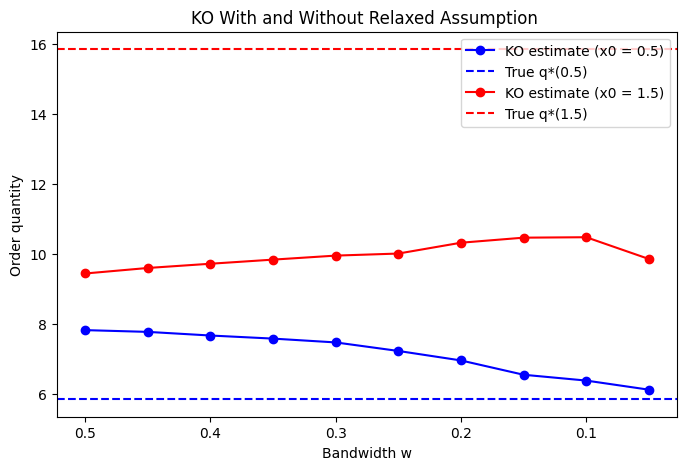

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42) # set seed value

# Model parameters
beta = 10
sigma = 1
r = 0.80

# inverse phi fn
Q_eps = norm.ppf(r)

# True optimal order quantity: q*(x) = beta*x + Q_epsilon(r)
def true_quantile(x):
    return beta*x + Q_eps

# Generate training data
# X ~ Uniform(0,1)
# epsilon ~ Normal(0,1)
# D = beta*X + epsilon
n = 800
X = np.random.uniform(0, 1, n)
epsilon = np.random.normal(0, sigma, n)
D = beta*X + epsilon

# Gaussian kernel
# K(u) = exp(-u^2 / 2) / sqrt(2*pi)
def gaussian_kernel(u):
    return np.exp(-0.5*u**2) / np.sqrt(2*np.pi)

# Kernel Optimization (KO) estimator
def KO_quantile(X, D, x0, w, r):
    # compute kernel weights
    weights = (1/w)*gaussian_kernel((x0 - X)/w)

    # sort demand values
    order = np.argsort(D)
    D_sorted = D[order]
    weights_sorted = weights[order]

    # construct weighted empirical cdf
    weighted_cdf = np.cumsum(weights_sorted) / np.sum(weights_sorted)

    # return first demand value where \ge r
    index = np.searchsorted(weighted_cdf, r)

    return D_sorted[index]

# various bandwidth values
bandwidths = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20, 0.15, 0.10, 0.05]

# Case 1: x0 = 0.5
x0_inside = 0.5
true_q_inside = true_quantile(x0_inside)
KO_inside = []
for w in bandwidths:
    q_hat = KO_quantile(X, D, x0_inside, w, r)
    KO_inside.append(q_hat)

# Case 2: x0 = 1.5
x0_outside = 1.5
true_q_outside = true_quantile(x0_outside)
KO_outside = []
for w in bandwidths:
    q_hat = KO_quantile(X, D, x0_outside, w, r)
    KO_outside.append(q_hat)

# Print
print("CASE 1: x0 = 0.5")
print("True q*(0.5):", round(true_q_inside, 3))
print("KO estimates:")
for w, qhat in zip(bandwidths, KO_inside):
    print("bandwidth =", w, " --> ", round(qhat, 3))

print("\n")

print("CASE 2: x0 = 1.5")
print("True q*(1.5):", round(true_q_outside, 3))
print("KO estimates:")
for w, qhat in zip(bandwidths, KO_outside):
    print("bandwidth =", w, " --> ", round(qhat, 3))

# Plot results
plt.figure(figsize=(8,5))

# Plot KO estimates for x0 = 0.5
plt.plot(
    bandwidths,
    KO_inside,
    marker='o',
    color='blue',
    label='KO estimate (x0 = 0.5)'
)

plt.axhline(
    true_q_inside,
    linestyle='--',
    color='blue',
    label='True q*(0.5)'
)

# Plot KO estimates for x0 = 1.5
plt.plot(
    bandwidths,
    KO_outside,
    marker='o',
    color='red',
    label='KO estimate (x0 = 1.5)'
)

plt.axhline(
    true_q_outside,
    linestyle='--',
    color='red',
    label='True q*(1.5)'
)

plt.xlabel("Bandwidth w")
plt.ylabel("Order quantity")
plt.title("KO With and Without Relaxed Assumption ")
plt.gca().invert_xaxis() # smaller bandwidths more right
plt.legend()
plt.show()